<a href="https://colab.research.google.com/github/aruna-31/Deep-Learning-practice-and-basic-projects/blob/main/Optimizers_with_activation_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from keras.callbacks import Callback

In [ ]:
from keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


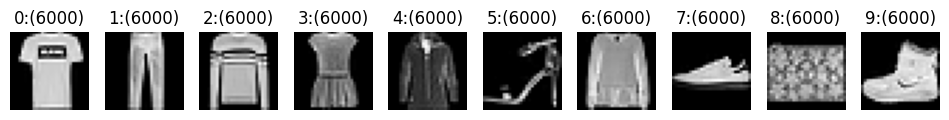

In [ ]:
import matplotlib.pyplot as plt

unique_labels = set(y_train)
plt.figure(figsize = (12,12))
i = 1
for label in unique_labels:
  image = X_train[y_train.tolist().index(label)]
  plt.subplot(10,10,i)
  plt.axis('off')
  plt.title("{0}:({1})".format(label,y_train.tolist().count(label)))
  i+=1
  _= plt.imshow(image,cmap = "gray")
plt.show()

In [ ]:
print(X_test)
print(y_test)

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]
[9 2 1 ... 8 1 5]


In [ ]:
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [ ]:
X_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [ ]:
n_classes = 10
y_train = to_categorical(y_train,n_classes)
y_test = to_categorical(y_test,n_classes)

In [ ]:
print(y_train)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [ ]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
model_sigmoid = Sequential()
model_sigmoid.add(Dense(512, input_dim=784, activation='sigmoid'))

model_sigmoid.add(Dense(256, activation='sigmoid'))
model_sigmoid.add(Dense(128, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))
model_sigmoid.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:


model_relu = Sequential()
model_relu.add(Dense(512, input_dim=784, activation='relu'))

model_relu.add(Dense(256, activation='relu'))
model_relu.add(Dense(128, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))


model_relu.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:
# Define the model with the ELU activation function

model_elu = Sequential()
model_elu.add(Dense(512, input_dim=784, activation='elu'))

model_elu.add(Dense(256, activation='elu'))
model_elu.add(Dense(128, activation='elu'))
model_elu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_elu.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:
# Define the model with the ReLU activation function

model_selu = Sequential()
model_selu.add(Dense(512, input_dim=784, activation='selu'))

model_selu.add(Dense(256, activation='selu'))
model_selu.add(Dense(128, activation='selu'))
model_selu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_selu.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:


model_gelu = Sequential()
model_gelu.add(Dense(512, input_dim=784, activation='gelu'))
model_gelu.add(Dense(256, activation='gelu'))

model_gelu.add(Dense(128, activation='gelu'))

model_gelu.add(Dense(10, activation='softmax'))


model_gelu.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [ ]:
from keras.layers import LeakyReLU



model_leakyrelu = Sequential()
model_leakyrelu.add(Dense(512, input_dim=784))
model_leakyrelu.add(LeakyReLU(alpha=0.1))

model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(256))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(128))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_leakyrelu.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:

class history_loss(Callback):
    def on_train_begin(self, logs={}):
        self.losses = []

    def on_batch_end(self, batch, logs={}):
        batch_loss = logs.get('loss')
        self.losses.append(batch_loss)

In [ ]:
n_epochs = 10
batch_size = 256
validation_split = 0.2

history_sigmoid = history_loss()
model_sigmoid.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_sigmoid],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 3s - 15ms/step - accuracy: 0.1146 - loss: 2.3155 - val_accuracy: 0.1077 - val_loss: 2.2991
Epoch 2/10
188/188 - 2s - 12ms/step - accuracy: 0.1405 - loss: 2.2959 - val_accuracy: 0.0983 - val_loss: 2.2932
Epoch 3/10
188/188 - 2s - 12ms/step - accuracy: 0.1867 - loss: 2.2905 - val_accuracy: 0.2878 - val_loss: 2.2873
Epoch 4/10
188/188 - 2s - 12ms/step - accuracy: 0.2580 - loss: 2.2848 - val_accuracy: 0.3352 - val_loss: 2.2814
Epoch 5/10
188/188 - 3s - 15ms/step - accuracy: 0.3019 - loss: 2.2787 - val_accuracy: 0.2418 - val_loss: 2.2753
Epoch 6/10
188/188 - 2s - 12ms/step - accuracy: 0.3461 - loss: 2.2720 - val_accuracy: 0.4696 - val_loss: 2.2679
Epoch 7/10
188/188 - 3s - 14ms/step - accuracy: 0.3729 - loss: 2.2643 - val_accuracy: 0.2882 - val_loss: 2.2604
Epoch 8/10
188/188 - 2s - 13ms/step - accuracy: 0.4098 - loss: 2.2559 - val_accuracy: 0.5157 - val_loss: 2.2504
Epoch 9/10
188/188 - 3s - 15ms/step - accuracy: 0.4578 - loss: 2.2457 - val_accuracy: 0.3658 - val_loss:

In [ ]:
history_relu = history_loss()
model_relu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_relu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 3s - 15ms/step - accuracy: 0.6039 - loss: 1.3892 - val_accuracy: 0.7179 - val_loss: 0.8940
Epoch 2/10
188/188 - 3s - 15ms/step - accuracy: 0.7474 - loss: 0.7812 - val_accuracy: 0.7728 - val_loss: 0.6893
Epoch 3/10
188/188 - 2s - 12ms/step - accuracy: 0.7854 - loss: 0.6540 - val_accuracy: 0.7865 - val_loss: 0.6227
Epoch 4/10
188/188 - 2s - 12ms/step - accuracy: 0.8039 - loss: 0.5908 - val_accuracy: 0.8103 - val_loss: 0.5684
Epoch 5/10
188/188 - 2s - 12ms/step - accuracy: 0.8148 - loss: 0.5514 - val_accuracy: 0.8084 - val_loss: 0.5614
Epoch 6/10
188/188 - 2s - 13ms/step - accuracy: 0.8217 - loss: 0.5260 - val_accuracy: 0.8063 - val_loss: 0.5472
Epoch 7/10
188/188 - 5s - 26ms/step - accuracy: 0.8283 - loss: 0.5054 - val_accuracy: 0.8279 - val_loss: 0.5102
Epoch 8/10
188/188 - 3s - 17ms/step - accuracy: 0.8322 - loss: 0.4896 - val_accuracy: 0.8278 - val_loss: 0.4938
Epoch 9/10
188/188 - 4s - 23ms/step - accuracy: 0.8351 - loss: 0.4776 - val_accuracy: 0.8321 - val_loss:

In [ ]:
history_elu = history_loss()
model_elu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_elu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 3s - 14ms/step - accuracy: 0.9015 - loss: 0.2533 - val_accuracy: 0.8859 - val_loss: 0.3199
Epoch 2/10
188/188 - 3s - 16ms/step - accuracy: 0.9062 - loss: 0.2430 - val_accuracy: 0.8734 - val_loss: 0.3733
Epoch 3/10
188/188 - 4s - 19ms/step - accuracy: 0.9108 - loss: 0.2356 - val_accuracy: 0.8808 - val_loss: 0.3635
Epoch 4/10
188/188 - 4s - 22ms/step - accuracy: 0.9122 - loss: 0.2258 - val_accuracy: 0.8831 - val_loss: 0.3563
Epoch 5/10
188/188 - 3s - 16ms/step - accuracy: 0.9163 - loss: 0.2185 - val_accuracy: 0.8805 - val_loss: 0.3601
Epoch 6/10
188/188 - 5s - 27ms/step - accuracy: 0.9189 - loss: 0.2108 - val_accuracy: 0.8798 - val_loss: 0.3473
Epoch 7/10
188/188 - 3s - 15ms/step - accuracy: 0.9220 - loss: 0.2037 - val_accuracy: 0.8754 - val_loss: 0.3738
Epoch 8/10
188/188 - 6s - 30ms/step - accuracy: 0.9255 - loss: 0.1941 - val_accuracy: 0.8808 - val_loss: 0.3719
Epoch 9/10
188/188 - 3s - 16ms/step - accuracy: 0.9268 - loss: 0.1878 - val_accuracy: 0.8804 - val_loss:

In [ ]:
history_selu = history_loss()
model_selu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_selu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 3s - 14ms/step - accuracy: 0.8984 - loss: 0.2645 - val_accuracy: 0.8585 - val_loss: 0.4103
Epoch 2/10
188/188 - 5s - 28ms/step - accuracy: 0.9043 - loss: 0.2532 - val_accuracy: 0.8539 - val_loss: 0.3982
Epoch 3/10
188/188 - 6s - 30ms/step - accuracy: 0.9051 - loss: 0.2479 - val_accuracy: 0.8807 - val_loss: 0.3455
Epoch 4/10
188/188 - 3s - 17ms/step - accuracy: 0.9103 - loss: 0.2344 - val_accuracy: 0.8716 - val_loss: 0.3607
Epoch 5/10
188/188 - 3s - 14ms/step - accuracy: 0.9113 - loss: 0.2297 - val_accuracy: 0.8783 - val_loss: 0.3545
Epoch 6/10
188/188 - 3s - 14ms/step - accuracy: 0.9142 - loss: 0.2251 - val_accuracy: 0.8703 - val_loss: 0.3810
Epoch 7/10
188/188 - 3s - 15ms/step - accuracy: 0.9174 - loss: 0.2150 - val_accuracy: 0.8816 - val_loss: 0.3670
Epoch 8/10
188/188 - 3s - 17ms/step - accuracy: 0.9208 - loss: 0.2061 - val_accuracy: 0.8731 - val_loss: 0.4054
Epoch 9/10
188/188 - 3s - 14ms/step - accuracy: 0.9227 - loss: 0.2009 - val_accuracy: 0.8805 - val_loss:

In [ ]:
history_gelu = history_loss()
model_gelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_gelu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 3s - 15ms/step - accuracy: 0.9155 - loss: 0.2192 - val_accuracy: 0.8828 - val_loss: 0.3406
Epoch 2/10
188/188 - 6s - 30ms/step - accuracy: 0.9201 - loss: 0.2051 - val_accuracy: 0.8888 - val_loss: 0.3329
Epoch 3/10
188/188 - 4s - 21ms/step - accuracy: 0.9238 - loss: 0.1965 - val_accuracy: 0.8895 - val_loss: 0.3263
Epoch 4/10
188/188 - 4s - 21ms/step - accuracy: 0.9293 - loss: 0.1844 - val_accuracy: 0.8758 - val_loss: 0.3773
Epoch 5/10
188/188 - 3s - 15ms/step - accuracy: 0.9316 - loss: 0.1775 - val_accuracy: 0.8808 - val_loss: 0.3437
Epoch 6/10
188/188 - 6s - 32ms/step - accuracy: 0.9349 - loss: 0.1677 - val_accuracy: 0.8813 - val_loss: 0.3963
Epoch 7/10
188/188 - 4s - 20ms/step - accuracy: 0.9368 - loss: 0.1612 - val_accuracy: 0.8898 - val_loss: 0.3588
Epoch 8/10
188/188 - 4s - 20ms/step - accuracy: 0.9403 - loss: 0.1511 - val_accuracy: 0.8924 - val_loss: 0.3625
Epoch 9/10
188/188 - 3s - 16ms/step - accuracy: 0.9421 - loss: 0.1459 - val_accuracy: 0.8902 - val_loss:

In [ ]:
history_leakyrelu = history_loss()
model_leakyrelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_leakyrelu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 4s - 21ms/step - accuracy: 0.7552 - loss: 0.6763 - val_accuracy: 0.8115 - val_loss: 0.5081
Epoch 2/10
188/188 - 4s - 22ms/step - accuracy: 0.8388 - loss: 0.4354 - val_accuracy: 0.8003 - val_loss: 0.5398
Epoch 3/10
188/188 - 2s - 13ms/step - accuracy: 0.8579 - loss: 0.3802 - val_accuracy: 0.8648 - val_loss: 0.3654
Epoch 4/10
188/188 - 3s - 14ms/step - accuracy: 0.8699 - loss: 0.3443 - val_accuracy: 0.8577 - val_loss: 0.3891
Epoch 5/10
188/188 - 3s - 16ms/step - accuracy: 0.8805 - loss: 0.3218 - val_accuracy: 0.8723 - val_loss: 0.3582
Epoch 6/10
188/188 - 3s - 14ms/step - accuracy: 0.8861 - loss: 0.3014 - val_accuracy: 0.8663 - val_loss: 0.3776
Epoch 7/10
188/188 - 2s - 13ms/step - accuracy: 0.8911 - loss: 0.2845 - val_accuracy: 0.8808 - val_loss: 0.3427
Epoch 8/10
188/188 - 3s - 14ms/step - accuracy: 0.8968 - loss: 0.2726 - val_accuracy: 0.8786 - val_loss: 0.3444
Epoch 9/10
188/188 - 3s - 15ms/step - accuracy: 0.9022 - loss: 0.2586 - val_accuracy: 0.8785 - val_loss:

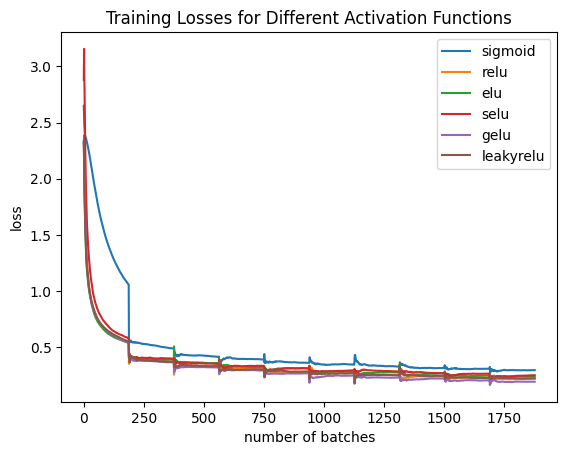

In [ ]:
plt.plot(np.arange(len(history_sigmoid.losses)), history_sigmoid.losses, label='sigmoid')
plt.plot(np.arange(len(history_relu.losses)), history_relu.losses, label='relu')
plt.plot(np.arange(len(history_elu.losses)), history_elu.losses, label='elu')
plt.plot(np.arange(len(history_selu.losses)), history_selu.losses, label='selu')
plt.plot(np.arange(len(history_gelu.losses)), history_gelu.losses, label='gelu')
plt.plot(np.arange(len(history_leakyrelu.losses)), history_leakyrelu.losses, label='leakyrelu')
plt.title('Training Losses for Different Activation Functions')
plt.xlabel('number of batches')
plt.ylabel('loss')
plt.legend(loc=1)
plt.show()

USING **RMSPROP**

In [ ]:
model_sigmoid = Sequential()
model_sigmoid.add(Dense(512, input_dim=784, activation='sigmoid'))

model_sigmoid.add(Dense(256, activation='sigmoid'))
model_sigmoid.add(Dense(128, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))
model_sigmoid.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [ ]:

model_relu = Sequential()
model_relu.add(Dense(512, input_dim=784, activation='relu'))

model_relu.add(Dense(256, activation='relu'))
model_relu.add(Dense(128, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))


model_relu.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [ ]:

model_elu = Sequential()
model_elu.add(Dense(512, input_dim=784, activation='elu'))

model_elu.add(Dense(256, activation='elu'))
model_elu.add(Dense(128, activation='elu'))
model_elu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_elu.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [ ]:
model_selu = Sequential()
model_selu.add(Dense(512, input_dim=784, activation='selu'))

model_selu.add(Dense(256, activation='selu'))
model_selu.add(Dense(128, activation='selu'))
model_selu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_selu.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [ ]:

model_gelu = Sequential()
model_gelu.add(Dense(512, input_dim=784, activation='gelu'))
model_gelu.add(Dense(256, activation='gelu'))

model_gelu.add(Dense(128, activation='gelu'))

model_gelu.add(Dense(10, activation='softmax'))


model_gelu.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [ ]:
from keras.layers import LeakyReLU



model_leakyrelu = Sequential()
model_leakyrelu.add(Dense(512, input_dim=784))
model_leakyrelu.add(LeakyReLU(alpha=0.1))

model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(256))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(128))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_leakyrelu.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [ ]:

class history_loss(Callback):
    def on_train_begin(self, logs={}):
        self.losses = []

    def on_batch_end(self, batch, logs={}):
        batch_loss = logs.get('loss')
        self.losses.append(batch_loss)

In [ ]:
n_epochs = 10
batch_size = 256
validation_split = 0.2

history_sigmoid = history_loss()
model_sigmoid.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_sigmoid],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 4s - 20ms/step - accuracy: 0.5721 - loss: 1.2334 - val_accuracy: 0.7075 - val_loss: 0.7679
Epoch 2/10
188/188 - 3s - 14ms/step - accuracy: 0.7662 - loss: 0.6300 - val_accuracy: 0.7737 - val_loss: 0.6083
Epoch 3/10
188/188 - 5s - 27ms/step - accuracy: 0.8031 - loss: 0.5361 - val_accuracy: 0.7732 - val_loss: 0.6089
Epoch 4/10
188/188 - 3s - 16ms/step - accuracy: 0.8219 - loss: 0.4900 - val_accuracy: 0.8157 - val_loss: 0.5046
Epoch 5/10
188/188 - 3s - 14ms/step - accuracy: 0.8332 - loss: 0.4593 - val_accuracy: 0.8139 - val_loss: 0.4912
Epoch 6/10
188/188 - 3s - 13ms/step - accuracy: 0.8389 - loss: 0.4381 - val_accuracy: 0.8438 - val_loss: 0.4239
Epoch 7/10
188/188 - 3s - 13ms/step - accuracy: 0.8474 - loss: 0.4206 - val_accuracy: 0.8432 - val_loss: 0.4279
Epoch 8/10
188/188 - 3s - 16ms/step - accuracy: 0.8511 - loss: 0.4080 - val_accuracy: 0.8462 - val_loss: 0.4098
Epoch 9/10
188/188 - 5s - 24ms/step - accuracy: 0.8572 - loss: 0.3953 - val_accuracy: 0.8517 - val_loss:

In [ ]:
history_relu = history_loss()
model_relu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_relu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 4s - 22ms/step - accuracy: 0.7530 - loss: 0.6802 - val_accuracy: 0.8051 - val_loss: 0.5534
Epoch 2/10
188/188 - 2s - 13ms/step - accuracy: 0.8340 - loss: 0.4421 - val_accuracy: 0.8116 - val_loss: 0.4933
Epoch 3/10
188/188 - 2s - 13ms/step - accuracy: 0.8577 - loss: 0.3785 - val_accuracy: 0.8479 - val_loss: 0.4094
Epoch 4/10
188/188 - 3s - 14ms/step - accuracy: 0.8701 - loss: 0.3468 - val_accuracy: 0.8279 - val_loss: 0.4513
Epoch 5/10
188/188 - 3s - 16ms/step - accuracy: 0.8785 - loss: 0.3229 - val_accuracy: 0.8766 - val_loss: 0.3479
Epoch 6/10
188/188 - 2s - 13ms/step - accuracy: 0.8856 - loss: 0.3033 - val_accuracy: 0.8781 - val_loss: 0.3360
Epoch 7/10
188/188 - 2s - 13ms/step - accuracy: 0.8930 - loss: 0.2835 - val_accuracy: 0.8571 - val_loss: 0.3992
Epoch 8/10
188/188 - 2s - 13ms/step - accuracy: 0.8987 - loss: 0.2712 - val_accuracy: 0.8787 - val_loss: 0.3445
Epoch 9/10
188/188 - 3s - 17ms/step - accuracy: 0.9015 - loss: 0.2578 - val_accuracy: 0.8633 - val_loss:

In [ ]:
history_elu = history_loss()
model_elu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_elu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 3s - 17ms/step - accuracy: 0.7370 - loss: 0.7409 - val_accuracy: 0.7872 - val_loss: 0.5834
Epoch 2/10
188/188 - 2s - 13ms/step - accuracy: 0.8244 - loss: 0.4691 - val_accuracy: 0.8005 - val_loss: 0.5144
Epoch 3/10
188/188 - 5s - 24ms/step - accuracy: 0.8461 - loss: 0.4090 - val_accuracy: 0.8478 - val_loss: 0.4014
Epoch 4/10
188/188 - 4s - 20ms/step - accuracy: 0.8594 - loss: 0.3703 - val_accuracy: 0.8599 - val_loss: 0.3765
Epoch 5/10
188/188 - 3s - 16ms/step - accuracy: 0.8717 - loss: 0.3404 - val_accuracy: 0.8485 - val_loss: 0.4152
Epoch 6/10
188/188 - 4s - 19ms/step - accuracy: 0.8781 - loss: 0.3224 - val_accuracy: 0.8634 - val_loss: 0.3714
Epoch 7/10
188/188 - 4s - 22ms/step - accuracy: 0.8833 - loss: 0.3051 - val_accuracy: 0.8798 - val_loss: 0.3467
Epoch 8/10
188/188 - 3s - 13ms/step - accuracy: 0.8887 - loss: 0.2911 - val_accuracy: 0.8723 - val_loss: 0.3533
Epoch 9/10
188/188 - 3s - 14ms/step - accuracy: 0.8944 - loss: 0.2768 - val_accuracy: 0.8622 - val_loss:

In [ ]:
history_selu = history_loss()
model_selu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_selu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 4s - 19ms/step - accuracy: 0.7103 - loss: 0.9522 - val_accuracy: 0.8137 - val_loss: 0.4980
Epoch 2/10
188/188 - 5s - 29ms/step - accuracy: 0.8099 - loss: 0.5134 - val_accuracy: 0.7903 - val_loss: 0.5968
Epoch 3/10
188/188 - 2s - 13ms/step - accuracy: 0.8361 - loss: 0.4362 - val_accuracy: 0.8184 - val_loss: 0.4728
Epoch 4/10
188/188 - 2s - 13ms/step - accuracy: 0.8527 - loss: 0.3925 - val_accuracy: 0.8583 - val_loss: 0.3813
Epoch 5/10
188/188 - 2s - 13ms/step - accuracy: 0.8654 - loss: 0.3574 - val_accuracy: 0.8423 - val_loss: 0.4114
Epoch 6/10
188/188 - 3s - 14ms/step - accuracy: 0.8730 - loss: 0.3377 - val_accuracy: 0.8678 - val_loss: 0.3600
Epoch 7/10
188/188 - 5s - 27ms/step - accuracy: 0.8792 - loss: 0.3189 - val_accuracy: 0.8419 - val_loss: 0.4330
Epoch 8/10
188/188 - 3s - 15ms/step - accuracy: 0.8864 - loss: 0.2997 - val_accuracy: 0.8583 - val_loss: 0.4055
Epoch 9/10
188/188 - 3s - 14ms/step - accuracy: 0.8916 - loss: 0.2874 - val_accuracy: 0.8347 - val_loss:

In [ ]:
history_gelu = history_loss()
model_gelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_gelu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 4s - 20ms/step - accuracy: 0.7555 - loss: 0.6659 - val_accuracy: 0.8289 - val_loss: 0.4713
Epoch 2/10
188/188 - 6s - 32ms/step - accuracy: 0.8390 - loss: 0.4282 - val_accuracy: 0.8282 - val_loss: 0.4663
Epoch 3/10
188/188 - 3s - 14ms/step - accuracy: 0.8600 - loss: 0.3726 - val_accuracy: 0.8460 - val_loss: 0.4296
Epoch 4/10
188/188 - 3s - 14ms/step - accuracy: 0.8718 - loss: 0.3375 - val_accuracy: 0.8705 - val_loss: 0.3503
Epoch 5/10
188/188 - 3s - 15ms/step - accuracy: 0.8821 - loss: 0.3109 - val_accuracy: 0.8370 - val_loss: 0.4641
Epoch 6/10
188/188 - 4s - 20ms/step - accuracy: 0.8884 - loss: 0.2918 - val_accuracy: 0.8704 - val_loss: 0.3598
Epoch 7/10
188/188 - 3s - 16ms/step - accuracy: 0.8956 - loss: 0.2726 - val_accuracy: 0.8707 - val_loss: 0.3397
Epoch 8/10
188/188 - 5s - 26ms/step - accuracy: 0.9021 - loss: 0.2551 - val_accuracy: 0.8922 - val_loss: 0.3018
Epoch 9/10
188/188 - 4s - 20ms/step - accuracy: 0.9068 - loss: 0.2434 - val_accuracy: 0.8828 - val_loss:

In [ ]:
history_leakyrelu = history_loss()
model_leakyrelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_leakyrelu],
 validation_split=validation_split, verbose=2)

Epoch 1/10
188/188 - 3s - 17ms/step - accuracy: 0.9091 - loss: 0.2380 - val_accuracy: 0.8823 - val_loss: 0.3317
Epoch 2/10
188/188 - 3s - 13ms/step - accuracy: 0.9128 - loss: 0.2276 - val_accuracy: 0.8811 - val_loss: 0.3358
Epoch 3/10
188/188 - 3s - 16ms/step - accuracy: 0.9150 - loss: 0.2211 - val_accuracy: 0.8853 - val_loss: 0.3298
Epoch 4/10
188/188 - 5s - 24ms/step - accuracy: 0.9190 - loss: 0.2137 - val_accuracy: 0.8572 - val_loss: 0.4228
Epoch 5/10
188/188 - 2s - 13ms/step - accuracy: 0.9210 - loss: 0.2055 - val_accuracy: 0.8767 - val_loss: 0.4169
Epoch 6/10
188/188 - 3s - 16ms/step - accuracy: 0.9237 - loss: 0.1988 - val_accuracy: 0.8898 - val_loss: 0.3267
Epoch 7/10
188/188 - 5s - 25ms/step - accuracy: 0.9269 - loss: 0.1894 - val_accuracy: 0.8818 - val_loss: 0.3758
Epoch 8/10
188/188 - 3s - 14ms/step - accuracy: 0.9291 - loss: 0.1845 - val_accuracy: 0.8687 - val_loss: 0.4005
Epoch 9/10
188/188 - 6s - 30ms/step - accuracy: 0.9310 - loss: 0.1786 - val_accuracy: 0.8759 - val_loss:

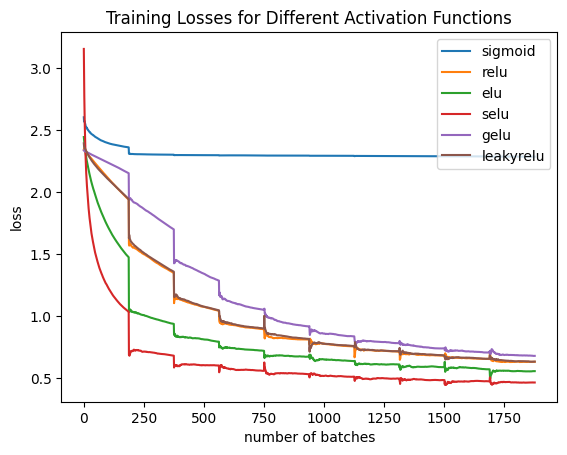

In [ ]:
plt.plot(np.arange(len(history_sigmoid.losses)), history_sigmoid.losses, label='sigmoid')
plt.plot(np.arange(len(history_relu.losses)), history_relu.losses, label='relu')
plt.plot(np.arange(len(history_elu.losses)), history_elu.losses, label='elu')
plt.plot(np.arange(len(history_selu.losses)), history_selu.losses, label='selu')
plt.plot(np.arange(len(history_gelu.losses)), history_gelu.losses, label='gelu')
plt.plot(np.arange(len(history_leakyrelu.losses)), history_leakyrelu.losses, label='leakyrelu')
plt.title('Training Losses for Different Activation Functions')
plt.xlabel('number of batches')
plt.ylabel('loss')
plt.legend(loc=1)
plt.show()

**USING ADAGRAD**

In [ ]:
model_sigmoid = Sequential()
model_sigmoid.add(Dense(512, input_dim=784, activation='sigmoid'))

model_sigmoid.add(Dense(256, activation='sigmoid'))
model_sigmoid.add(Dense(128, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))
model_sigmoid.compile(loss='categorical_crossentropy', optimizer='adagrad', metrics=['accuracy'])


model_relu = Sequential()
model_relu.add(Dense(512, input_dim=784, activation='relu'))
model_relu.add(Dense(256, activation='relu'))
model_relu.add(Dense(128, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))
model_relu.compile(loss='categorical_crossentropy', optimizer='adagrad', metrics=['accuracy'])


model_elu = Sequential()
model_elu.add(Dense(512, input_dim=784, activation='elu'))
model_elu.add(Dense(256, activation='elu'))
model_elu.add(Dense(128, activation='elu'))
model_elu.add(Dense(10, activation='softmax'))
model_elu.compile(loss='categorical_crossentropy', optimizer='adagrad', metrics=['accuracy'])

model_selu = Sequential()
model_selu.add(Dense(512, input_dim=784, activation='selu'))

model_selu.add(Dense(256, activation='selu'))
model_selu.add(Dense(128, activation='selu'))
model_selu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_selu.compile(loss='categorical_crossentropy', optimizer='adagrad', metrics=['accuracy'])


model_gelu = Sequential()
model_gelu.add(Dense(512, input_dim=784, activation='gelu'))
model_gelu.add(Dense(256, activation='gelu'))
model_gelu.add(Dense(128, activation='gelu'))
model_gelu.add(Dense(10, activation='softmax'))
model_gelu.compile(loss='categorical_crossentropy', optimizer='adagrad', metrics=['accuracy'])

from keras.layers import LeakyReLU
model_leakyrelu = Sequential()
model_leakyrelu.add(Dense(512, input_dim=784))
model_leakyrelu.add(LeakyReLU(alpha=0.1))

model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(256))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(128))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(10, activation='softmax'))


model_leakyrelu.compile(loss='categorical_crossentropy', optimizer='adagrad', metrics=['accuracy'])




In [ ]:


class history_loss(Callback):
    def on_train_begin(self, logs={}):
        self.losses = []

    def on_batch_end(self, batch, logs={}):
        batch_loss = logs.get('loss')
        self.losses.append(batch_loss)

In [ ]:
n_epochs = 10
batch_size = 256
validation_split = 0.2

history_sigmoid = history_loss()
model_sigmoid.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_sigmoid],
 validation_split=validation_split, verbose=2)

history_relu = history_loss()
model_relu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_relu],
 validation_split=validation_split, verbose=2)

history_elu = history_loss()
model_elu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_elu],
 validation_split=validation_split, verbose=2)

history_selu = history_loss()
model_selu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_selu],
 validation_split=validation_split, verbose=2)

history_gelu = history_loss()
model_gelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_gelu],
 validation_split=validation_split, verbose=2)

history_leakyrelu = history_loss()
model_leakyrelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_leakyrelu],
 validation_split=validation_split, verbose= 2)





Epoch 1/10
188/188 - 3s - 16ms/step - accuracy: 0.0997 - loss: 2.3611 - val_accuracy: 0.1013 - val_loss: 2.3070
Epoch 2/10
188/188 - 2s - 13ms/step - accuracy: 0.0997 - loss: 2.3019 - val_accuracy: 0.1013 - val_loss: 2.2986
Epoch 3/10
188/188 - 3s - 14ms/step - accuracy: 0.1295 - loss: 2.2979 - val_accuracy: 0.1840 - val_loss: 2.2969
Epoch 4/10
188/188 - 3s - 15ms/step - accuracy: 0.1745 - loss: 2.2961 - val_accuracy: 0.2766 - val_loss: 2.2952
Epoch 5/10
188/188 - 3s - 15ms/step - accuracy: 0.2355 - loss: 2.2945 - val_accuracy: 0.2573 - val_loss: 2.2937
Epoch 6/10
188/188 - 2s - 13ms/step - accuracy: 0.2070 - loss: 2.2929 - val_accuracy: 0.2856 - val_loss: 2.2920
Epoch 7/10
188/188 - 2s - 13ms/step - accuracy: 0.3161 - loss: 2.2913 - val_accuracy: 0.2899 - val_loss: 2.2904
Epoch 8/10
188/188 - 2s - 13ms/step - accuracy: 0.2937 - loss: 2.2896 - val_accuracy: 0.3668 - val_loss: 2.2887
Epoch 9/10
188/188 - 3s - 18ms/step - accuracy: 0.3441 - loss: 2.2879 - val_accuracy: 0.3207 - val_loss:

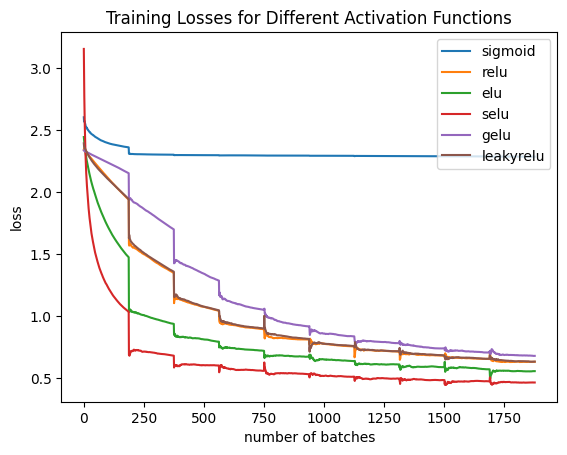

In [ ]:
plt.plot(np.arange(len(history_sigmoid.losses)), history_sigmoid.losses, label='sigmoid')
plt.plot(np.arange(len(history_relu.losses)), history_relu.losses, label='relu')
plt.plot(np.arange(len(history_elu.losses)), history_elu.losses, label='elu')
plt.plot(np.arange(len(history_selu.losses)), history_selu.losses, label='selu')
plt.plot(np.arange(len(history_gelu.losses)), history_gelu.losses, label='gelu')
plt.plot(np.arange(len(history_leakyrelu.losses)), history_leakyrelu.losses, label='leakyrelu')
plt.title('Training Losses for Different Activation Functions')
plt.xlabel('number of batches')
plt.ylabel('loss')
plt.legend(loc=1)
plt.show()

**USING ADAMAX**

In [ ]:
model_sigmoid = Sequential()
model_sigmoid.add(Dense(512, input_dim=784, activation='sigmoid'))

model_sigmoid.add(Dense(256, activation='sigmoid'))
model_sigmoid.add(Dense(128, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))
model_sigmoid.compile(loss='categorical_crossentropy', optimizer='adamax', metrics=['accuracy'])


model_relu = Sequential()
model_relu.add(Dense(512, input_dim=784, activation='relu'))
model_relu.add(Dense(256, activation='relu'))
model_relu.add(Dense(128, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))
model_relu.compile(loss='categorical_crossentropy', optimizer='adamax', metrics=['accuracy'])


model_elu = Sequential()
model_elu.add(Dense(512, input_dim=784, activation='elu'))
model_elu.add(Dense(256, activation='elu'))
model_elu.add(Dense(128, activation='elu'))
model_elu.add(Dense(10, activation='softmax'))
model_elu.compile(loss='categorical_crossentropy', optimizer='adamax', metrics=['accuracy'])

model_selu = Sequential()
model_selu.add(Dense(512, input_dim=784, activation='selu'))

model_selu.add(Dense(256, activation='selu'))
model_selu.add(Dense(128, activation='selu'))
model_selu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_selu.compile(loss='categorical_crossentropy', optimizer='adamax', metrics=['accuracy'])


model_gelu = Sequential()
model_gelu.add(Dense(512, input_dim=784, activation='gelu'))
model_gelu.add(Dense(256, activation='gelu'))
model_gelu.add(Dense(128, activation='gelu'))
model_gelu.add(Dense(10, activation='softmax'))
model_gelu.compile(loss='categorical_crossentropy', optimizer='adamax', metrics=['accuracy'])

from keras.layers import LeakyReLU
model_leakyrelu = Sequential()
model_leakyrelu.add(Dense(512, input_dim=784))
model_leakyrelu.add(LeakyReLU(alpha=0.1))

model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(256))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(128))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(10, activation='softmax'))


model_leakyrelu.compile(loss='categorical_crossentropy', optimizer='adamax', metrics=['accuracy'])




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:

class history_loss(Callback):
    def on_train_begin(self, logs={}):
        self.losses = []

    def on_batch_end(self, batch, logs={}):
        batch_loss = logs.get('loss')
        self.losses.append(batch_loss)

In [ ]:
n_epochs = 10
batch_size = 256
validation_split = 0.2

history_sigmoid = history_loss()
model_sigmoid.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_sigmoid],
 validation_split=validation_split, verbose=2)

history_relu = history_loss()
model_relu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_relu],
 validation_split=validation_split, verbose=2)

history_elu = history_loss()
model_elu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_elu],
 validation_split=validation_split, verbose=2)

history_selu = history_loss()
model_selu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_selu],
 validation_split=validation_split, verbose=2)

history_gelu = history_loss()
model_gelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_gelu],
 validation_split=validation_split, verbose=2)

history_leakyrelu = history_loss()
model_leakyrelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_leakyrelu],
 validation_split=validation_split, verbose= 2)





Epoch 1/10
188/188 - 4s - 19ms/step - accuracy: 0.5976 - loss: 1.3063 - val_accuracy: 0.7382 - val_loss: 0.7643
Epoch 2/10
188/188 - 5s - 26ms/step - accuracy: 0.7734 - loss: 0.6460 - val_accuracy: 0.8036 - val_loss: 0.5622
Epoch 3/10
188/188 - 3s - 14ms/step - accuracy: 0.8190 - loss: 0.5196 - val_accuracy: 0.8249 - val_loss: 0.4924
Epoch 4/10
188/188 - 6s - 31ms/step - accuracy: 0.8371 - loss: 0.4641 - val_accuracy: 0.8342 - val_loss: 0.4551
Epoch 5/10
188/188 - 3s - 14ms/step - accuracy: 0.8464 - loss: 0.4341 - val_accuracy: 0.8447 - val_loss: 0.4277
Epoch 6/10
188/188 - 3s - 14ms/step - accuracy: 0.8542 - loss: 0.4119 - val_accuracy: 0.8523 - val_loss: 0.4099
Epoch 7/10
188/188 - 3s - 14ms/step - accuracy: 0.8596 - loss: 0.3959 - val_accuracy: 0.8536 - val_loss: 0.4082
Epoch 8/10
188/188 - 4s - 19ms/step - accuracy: 0.8634 - loss: 0.3831 - val_accuracy: 0.8600 - val_loss: 0.3899
Epoch 9/10
188/188 - 3s - 14ms/step - accuracy: 0.8661 - loss: 0.3718 - val_accuracy: 0.8626 - val_loss:

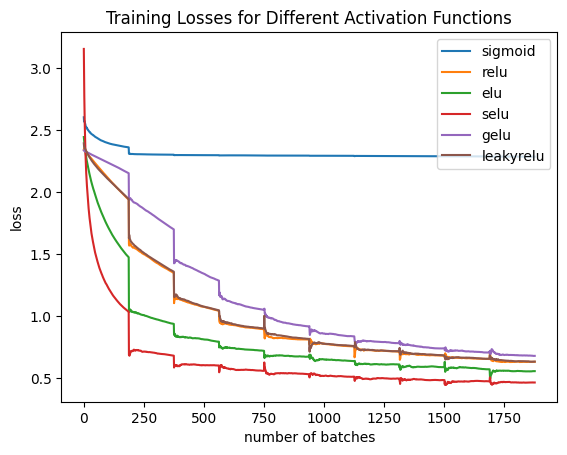

In [ ]:
plt.plot(np.arange(len(history_sigmoid.losses)), history_sigmoid.losses, label='sigmoid')
plt.plot(np.arange(len(history_relu.losses)), history_relu.losses, label='relu')
plt.plot(np.arange(len(history_elu.losses)), history_elu.losses, label='elu')
plt.plot(np.arange(len(history_selu.losses)), history_selu.losses, label='selu')
plt.plot(np.arange(len(history_gelu.losses)), history_gelu.losses, label='gelu')
plt.plot(np.arange(len(history_leakyrelu.losses)), history_leakyrelu.losses, label='leakyrelu')
plt.title('Training Losses for Different Activation Functions')
plt.xlabel('number of batches')
plt.ylabel('loss')
plt.legend(loc=1)
plt.show()

**USING ADAM**

In [ ]:
model_sigmoid = Sequential()
model_sigmoid.add(Dense(512, input_dim=784, activation='sigmoid'))

model_sigmoid.add(Dense(256, activation='sigmoid'))
model_sigmoid.add(Dense(128, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))
model_sigmoid.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


model_relu = Sequential()
model_relu.add(Dense(512, input_dim=784, activation='relu'))
model_relu.add(Dense(256, activation='relu'))
model_relu.add(Dense(128, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))
model_relu.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


model_elu = Sequential()
model_elu.add(Dense(512, input_dim=784, activation='elu'))
model_elu.add(Dense(256, activation='elu'))
model_elu.add(Dense(128, activation='elu'))
model_elu.add(Dense(10, activation='softmax'))
model_elu.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_selu = Sequential()
model_selu.add(Dense(512, input_dim=784, activation='selu'))

model_selu.add(Dense(256, activation='selu'))
model_selu.add(Dense(128, activation='selu'))
model_selu.add(Dense(10, activation='softmax'))

# Compile model with SGD
model_selu.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


model_gelu = Sequential()
model_gelu.add(Dense(512, input_dim=784, activation='gelu'))
model_gelu.add(Dense(256, activation='gelu'))
model_gelu.add(Dense(128, activation='gelu'))
model_gelu.add(Dense(10, activation='softmax'))
model_gelu.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

from keras.layers import LeakyReLU
model_leakyrelu = Sequential()
model_leakyrelu.add(Dense(512, input_dim=784))
model_leakyrelu.add(LeakyReLU(alpha=0.1))

model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(256))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(128))
model_leakyrelu.add(LeakyReLU(alpha=0.1))
model_leakyrelu.add(Dense(10, activation='softmax'))


model_leakyrelu.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:

class history_loss(Callback):
    def on_train_begin(self, logs={}):
        self.losses = []

    def on_batch_end(self, batch, logs={}):
        batch_loss = logs.get('loss')
        self.losses.append(batch_loss)

In [ ]:
n_epochs = 10
batch_size = 256
validation_split = 0.2

history_sigmoid = history_loss()
model_sigmoid.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_sigmoid],
 validation_split=validation_split, verbose=2)

history_relu = history_loss()
model_relu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_relu],
 validation_split=validation_split, verbose=2)

history_elu = history_loss()
model_elu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_elu],
 validation_split=validation_split, verbose=2)

history_selu = history_loss()
model_selu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_selu],
 validation_split=validation_split, verbose=2)

history_gelu = history_loss()
model_gelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_gelu],
 validation_split=validation_split, verbose=2)

history_leakyrelu = history_loss()
model_leakyrelu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
 callbacks=[history_leakyrelu],
 validation_split=validation_split, verbose= 2)

Epoch 1/10
188/188 - 4s - 22ms/step - accuracy: 0.6408 - loss: 1.0591 - val_accuracy: 0.8030 - val_loss: 0.5570
Epoch 2/10
188/188 - 6s - 29ms/step - accuracy: 0.8267 - loss: 0.4893 - val_accuracy: 0.8379 - val_loss: 0.4490
Epoch 3/10
188/188 - 3s - 14ms/step - accuracy: 0.8519 - loss: 0.4176 - val_accuracy: 0.8553 - val_loss: 0.4056
Epoch 4/10
188/188 - 3s - 14ms/step - accuracy: 0.8592 - loss: 0.3908 - val_accuracy: 0.8597 - val_loss: 0.3844
Epoch 5/10
188/188 - 3s - 14ms/step - accuracy: 0.8709 - loss: 0.3621 - val_accuracy: 0.8666 - val_loss: 0.3701
Epoch 6/10
188/188 - 3s - 16ms/step - accuracy: 0.8749 - loss: 0.3466 - val_accuracy: 0.8700 - val_loss: 0.3554
Epoch 7/10
188/188 - 3s - 14ms/step - accuracy: 0.8813 - loss: 0.3292 - val_accuracy: 0.8740 - val_loss: 0.3467
Epoch 8/10
188/188 - 5s - 27ms/step - accuracy: 0.8855 - loss: 0.3174 - val_accuracy: 0.8763 - val_loss: 0.3412
Epoch 9/10
188/188 - 4s - 20ms/step - accuracy: 0.8879 - loss: 0.3095 - val_accuracy: 0.8726 - val_loss:

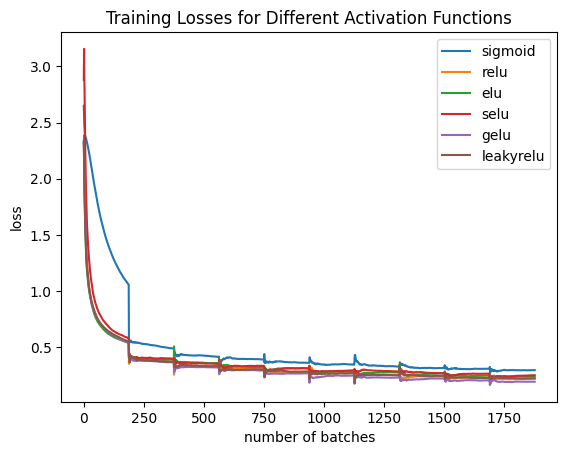

In [ ]:
plt.plot(np.arange(len(history_sigmoid.losses)), history_sigmoid.losses, label='sigmoid')
plt.plot(np.arange(len(history_relu.losses)), history_relu.losses, label='relu')
plt.plot(np.arange(len(history_elu.losses)), history_elu.losses, label='elu')
plt.plot(np.arange(len(history_selu.losses)), history_selu.losses, label='selu')
plt.plot(np.arange(len(history_gelu.losses)), history_gelu.losses, label='gelu')
plt.plot(np.arange(len(history_leakyrelu.losses)), history_leakyrelu.losses, label='leakyrelu')
plt.title('Training Losses for Different Activation Functions')
plt.xlabel('number of batches')
plt.ylabel('loss')
plt.legend(loc=1)
plt.show()